In [1]:
import os
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO
import requests
import random
import sys
sys.path.append("../playdarts/")
from dataset import DartsDataset
%load_ext autoreload
%autoreload 2

In [60]:
from rfdetr import RFDETRNano, RFDETRSmall

model = RFDETRNano(lite_refpoint_refine=False, pretrain_weights="outputs/output_dual_4_points_weighted_loss/eval/checkpoint_best_total.pth", num_boxes_per_query=2, dec_n_points=4, device="cpu")

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


num_classes mismatch: pretrain weights has 5 classes, but your model has 90 classes
reinitializing detection head with 5 classes


Loading pretrain weights


In [ ]:
# url = "https://media.roboflow.com/dog.jpeg"
image = Image.open("../playdarts/dataset_dual_corners/test/0eed11aa-2573-41ed-94a8-8d91fb9fbc8c.jpg")
# image = Image.open("../playdarts/my_unlabelled/vids/frames_0000/output_0121.jpg")
dataset = DartsDataset(dirs=["../playdarts/my_unlabelled/vids/frames_0006"], random_rotation=False, is_synthetic=False)
# name, image, ann, image2, ann2 = dataset[34]
# image = Image.open("../playdarts/thommy/_IMG0813.jpg")
# image = image.rotate(270, expand=True)

In [67]:
predictions = model.predict(image, threshold=0.4)

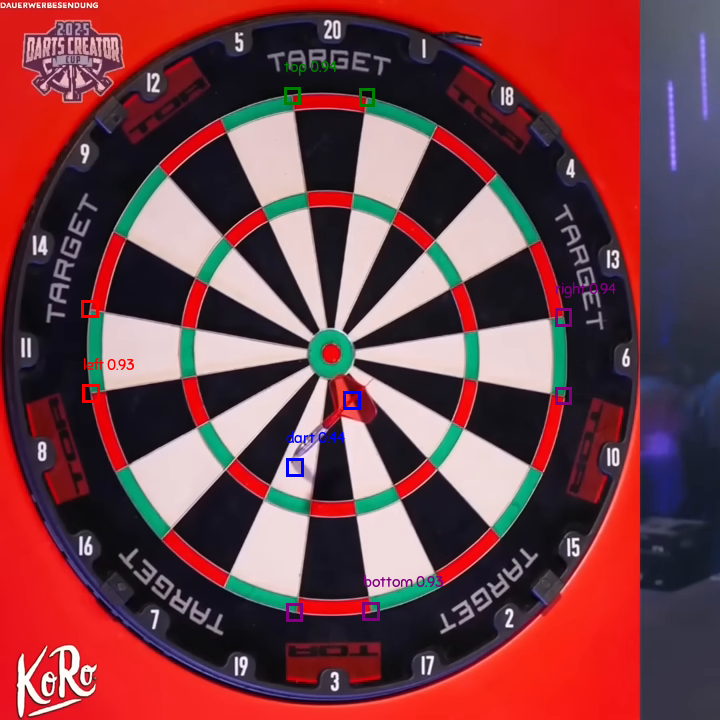

In [68]:
draw = ImageDraw.Draw(image)
fontsize = 15
font = ImageFont.truetype("C://Users/Tim/Documents/dev/playdarts/3D/scene/fonts/sniglet/Sniglet-Regular.ttf", size=fontsize)
for xyxy, conf, cls in zip(predictions.xyxy.reshape(-1, 8), predictions.confidence.reshape(-1, 2)[:, 0], predictions.class_id.reshape(-1, 2)[:, 0]):
    # if cls not in model.class_names.keys():
    #     continue
    colors = ["red", "blue", "green", "yellow", "purple", "orange"]
    color = random.choice(colors)
    draw.rectangle(xyxy[:4], outline=color, width=3)
    draw.rectangle(xyxy[4:], outline=color, width=3)
    # draw.line((xyxy[0::2].mean(), xyxy[1::2].mean(), xyxy[4::2].mean(), xyxy[5::2].mean()), fill=color, width=3)
    draw.text((xyxy[0], xyxy[1] - 2*fontsize), f"{model.class_names[cls]} {conf:.2f}", fill=color, font=font)
    # draw.text((xyxy[4], xyxy[5] - 2*fontsize), f"{model.class_names[cls]} {conf:.2f}", fill=color, font=font)
image

In [69]:
model.means

[0.485, 0.456, 0.406]

In [70]:
coreml_model = model.export_coreml(output_dir="output")

Exporting model to CoreML format
It seems some dependencies for CoreML export are missing.


ModuleNotFoundError: No module named 'coremltools'

In [ ]:
import torch
import supervision as sv

In [ ]:
def process_coreml_output(output, threshold, orig_size):
    predictions = {
        "pred_logits": torch.from_numpy(output["labels"]).to(model.model.device),
        "pred_boxes": torch.from_numpy(output["dets"]).to(model.model.device)
    }

    target_sizes = torch.tensor([(orig_size[1], orig_size[0])], device=model.model.device)
    results = model.model.postprocessors["bbox"](predictions, target_sizes=target_sizes)

    detections_list = []
    for result in results:
        scores = result["scores"]
        labels = result["labels"]
        boxes = result["boxes"]

        keep = scores > threshold
        scores = scores[keep]
        labels = labels[keep]
        boxes = boxes[keep]

        detections = sv.Detections(
            xyxy=boxes.float().cpu().numpy(),
            confidence=scores.float().cpu().numpy(),
            class_id=labels.cpu().numpy(),
        )
        detections_list.append(detections)

    return detections_list if len(detections_list) > 1 else detections_list[0]

In [ ]:
import numpy as np

In [ ]:
image = Image.open(BytesIO(requests.get(url).content))
# image = image.rotate(270, expand=True)
orig_size = image.size

In [ ]:
output = coreml_model.predict({"input": image.resize((model.model.resolution, model.model.resolution))})
predictions = process_coreml_output(output, threshold=0.5, orig_size=orig_size)
predictions

Detections(xyxy=array([[  62.735905 ,  247.44942  ,  650.7225   ,  932.52716  ],
       [   1.4309907,  362.4046   ,  649.52966  , 1263.113    ],
       [ 622.45447  ,  720.3906   ,  698.7641   ,  787.94385  ]],
      dtype=float32), mask=None, confidence=array([0.8700627 , 0.7715313 , 0.51659745], dtype=float32), class_id=array([18,  1,  3]), tracker_id=None, data={}, metadata={})

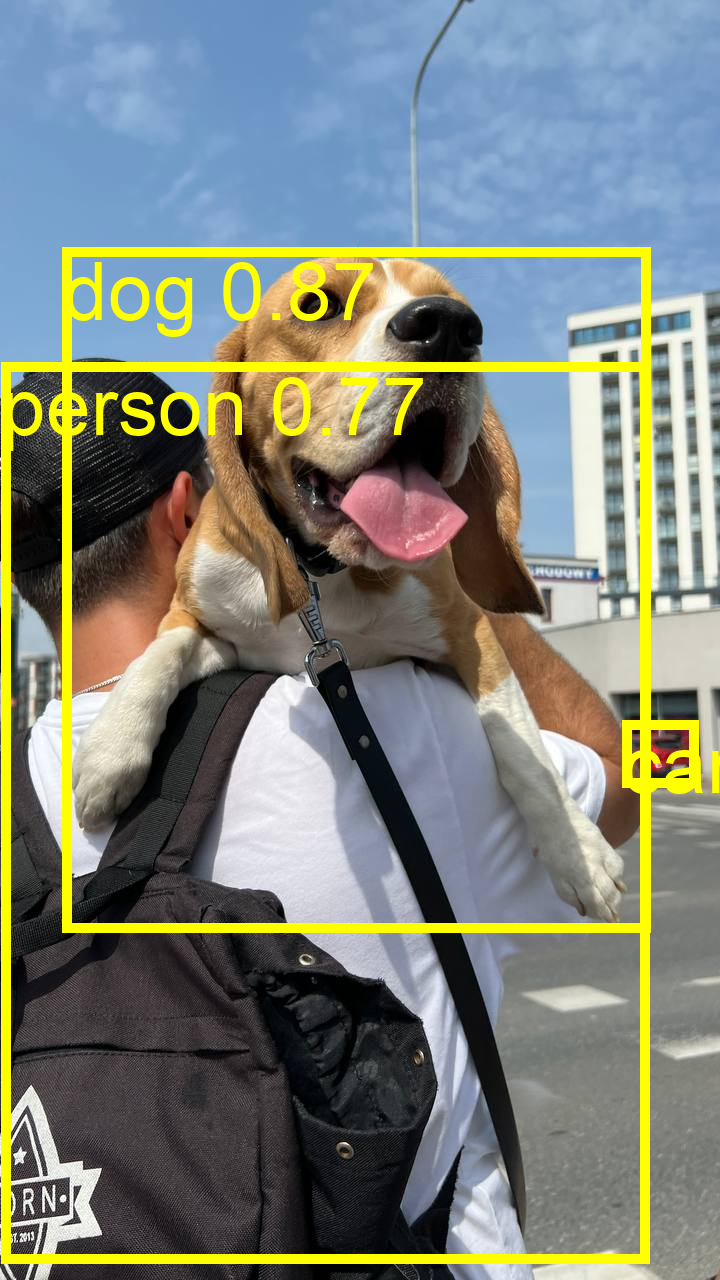

In [ ]:
draw = ImageDraw.Draw(image)
font = ImageFont.truetype("/System/Library/Fonts/Supplemental/Arial.ttf", size=80)
for xyxy, conf, cls in zip(predictions.xyxy, predictions.confidence, predictions.class_id):
    draw.rectangle(xyxy, outline="yellow", width=10)
    draw.text((xyxy[0], xyxy[1]), f"{model.class_names[cls]} {conf:.2f}", fill="yellow", font=font)
image